In [ ]:
# Agribusiness Crop Yield Analysis

## Week 1: Data Collection and Data Cleaning

### Internship Project

**Objective:**  
To collect, inspect, clean, validate and prepare an agricultural dataset for further Exploratory Data Analysis and Machine Learning.

**Dataset:** Crop Yield of a Farm

**Week 1 Activities:**
- Data Collection
- Dataset Inspection
- Missing Value Analysis
- Duplicate Detection
- Data Type Validation
- Invalid Value Detection
- Outlier Detection
- Data Cleaning
- Statistical Summary
- Cleaned Dataset Export

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
dataset_path = "../Dataset/original_dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head(5)

,rainfall_mm,soil_quality_index,farm_size_hectares,sunlight_hours,fertilizer_kg,crop_yield
0,1626,9,636,11,1006,404
1,1959,9,73,11,112,115
2,1360,1,352,5,702,231
3,1794,2,948,7,299,537
4,1630,5,884,5,2733,554


In [4]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 3000
Number of Columns: 6


In [5]:
print("Dataset Columns:\n")

for column in df.columns:
    print("-", column)

Dataset Columns:

- rainfall_mm
- soil_quality_index
- farm_size_hectares
- sunlight_hours
- fertilizer_kg
- crop_yield


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   rainfall_mm         3000 non-null   int64
 1   soil_quality_index  3000 non-null   int64
 2   farm_size_hectares  3000 non-null   int64
 3   sunlight_hours      3000 non-null   int64
 4   fertilizer_kg       3000 non-null   int64
 5   crop_yield          3000 non-null   int64
dtypes: int64(6)
memory usage: 140.8 KB


In [7]:
print("Data Types:\n")
print(df.dtypes)

Data Types:

rainfall_mm           int64
soil_quality_index    int64
farm_size_hectares    int64
sunlight_hours        int64
fertilizer_kg         int64
crop_yield            int64
dtype: object


In [8]:
df.describe()

,rainfall_mm,soil_quality_index,farm_size_hectares,sunlight_hours,fertilizer_kg,crop_yield
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1263.095000,5.506667,498.801000,7.995333,1549.450333,328.099000
std,432.371756,2.855172,287.122742,2.621501,814.326919,145.036503
min,500.000000,1.000000,10.000000,4.000000,100.000000,46.000000
25%,896.000000,3.000000,242.000000,6.000000,869.750000,199.000000
50%,1277.000000,6.000000,505.000000,8.000000,1542.000000,332.000000
75%,1636.000000,8.000000,741.000000,10.000000,2225.000000,455.000000
max,2000.000000,10.000000,1000.000000,12.000000,3000.000000,628.000000


In [9]:
missing_count = df.isnull().sum()

print("Missing Values:\n")
print(missing_count)

Missing Values:

rainfall_mm           0
soil_quality_index    0
farm_size_hectares    0
sunlight_hours        0
fertilizer_kg         0
crop_yield            0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

display(missing_report)

,Missing Count,Missing Percentage
rainfall_mm,0,0.0
soil_quality_index,0,0.0
farm_size_hectares,0,0.0
sunlight_hours,0,0.0
fertilizer_kg,0,0.0
crop_yield,0,0.0


In [11]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Missing value treatment completed.")

Missing value treatment completed.


In [13]:
print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
rainfall_mm           0
soil_quality_index    0
farm_size_hectares    0
sunlight_hours        0
fertilizer_kg         0
crop_yield            0
dtype: int64


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [15]:
df = df.drop_duplicates()

print("Duplicate rows removed.")
print("Current Dataset Shape:", df.shape)

Duplicate rows removed.
Current Dataset Shape: (3000, 6)


In [16]:
print("========== INVALID VALUE CHECK ==========")

print(
    "Negative rainfall:",
    (df["rainfall_mm"] < 0).sum()
)

print(
    "Invalid soil quality:",
    ((df["soil_quality_index"] < 1) |
     (df["soil_quality_index"] > 10)).sum()
)

print(
    "Invalid farm size:",
    (df["farm_size_hectares"] <= 0).sum()
)

print(
    "Invalid sunlight:",
    ((df["sunlight_hours"] < 0) |
     (df["sunlight_hours"] > 24)).sum()
)

print(
    "Negative fertilizer:",
    (df["fertilizer_kg"] < 0).sum()
)

print(
    "Negative crop yield:",
    (df["crop_yield"] < 0).sum()
)

========== INVALID VALUE CHECK ==========
Negative rainfall: 0
Invalid soil quality: 0
Invalid farm size: 0
Invalid sunlight: 0
Negative fertilizer: 0
Negative crop yield: 0


In [17]:
before_cleaning = len(df)

df = df[
    (df["rainfall_mm"] >= 0) &
    (df["soil_quality_index"] >= 1) &
    (df["soil_quality_index"] <= 10) &
    (df["farm_size_hectares"] > 0) &
    (df["sunlight_hours"] >= 0) &
    (df["sunlight_hours"] <= 24) &
    (df["fertilizer_kg"] >= 0) &
    (df["crop_yield"] >= 0)
]

after_cleaning = len(df)

print("Rows before validation:", before_cleaning)
print("Rows after validation:", after_cleaning)
print("Rows removed:", before_cleaning - after_cleaning)

Rows before validation: 3000
Rows after validation: 3000
Rows removed: 0


In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_report = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_report.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_df = pd.DataFrame(outlier_report)

display(outlier_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,rainfall_mm,896.00,1636.0,740.00,-214.000,2746.000,0
1,soil_quality_index,3.00,8.0,5.00,-4.500,15.500,0
2,farm_size_hectares,242.00,741.0,499.00,-506.500,1489.500,0
3,sunlight_hours,6.00,10.0,4.00,0.000,16.000,0
4,fertilizer_kg,869.75,2225.0,1355.25,-1163.125,4257.875,0
5,crop_yield,199.00,455.0,256.00,-185.000,839.000,0


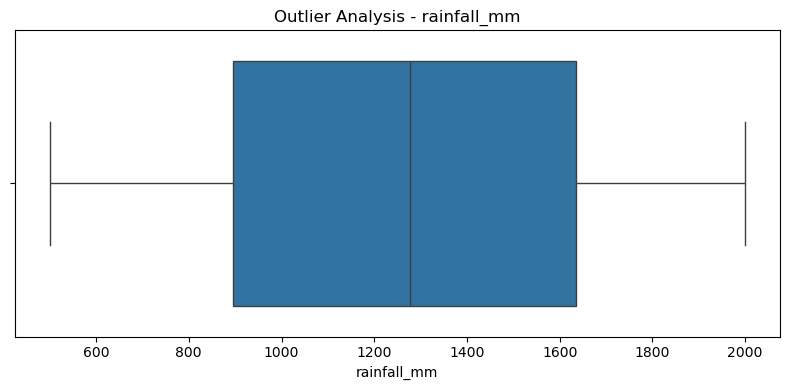

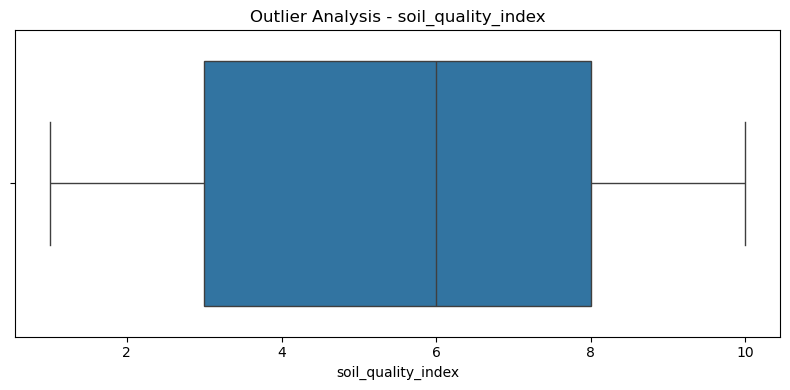

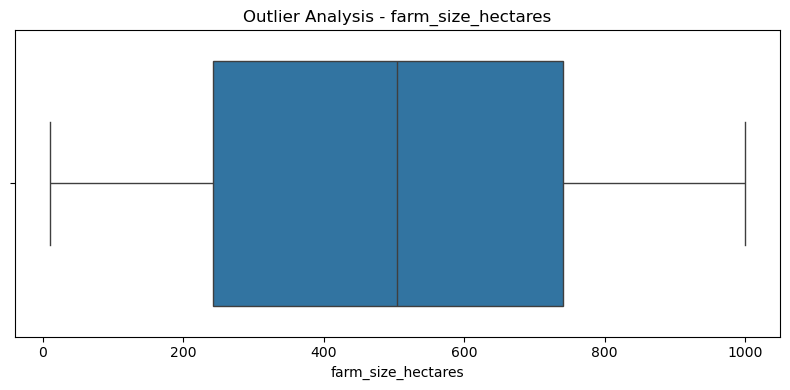

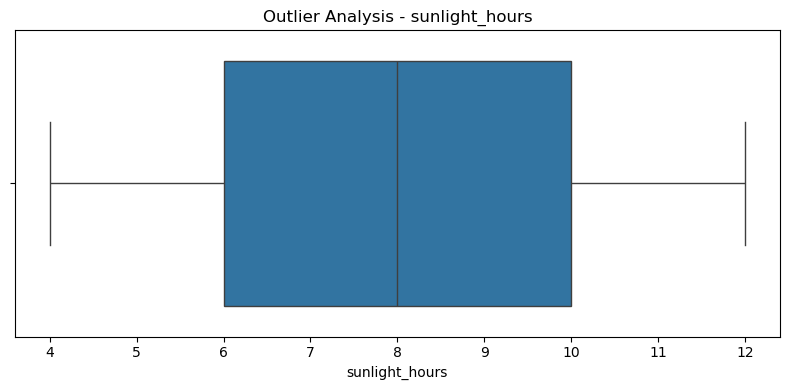

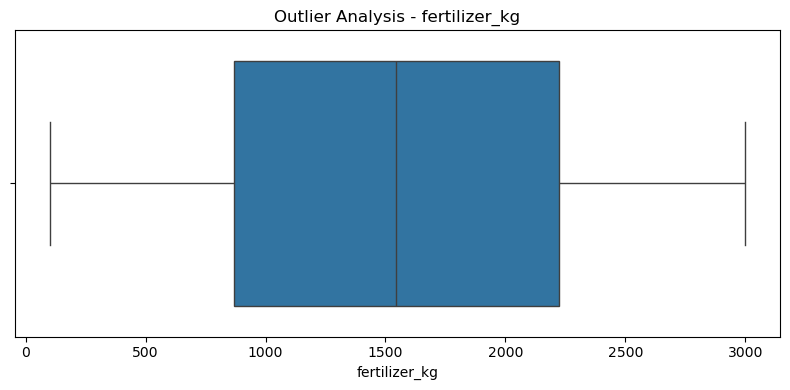

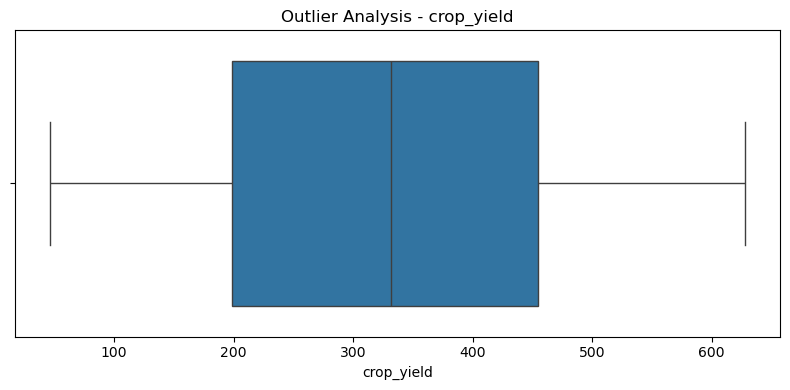

In [26]:
for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Outlier Analysis - {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [20]:
statistical_summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Standard Deviation": df.std(numeric_only=True),
    "Minimum": df.min(numeric_only=True),
    "Q1": df.quantile(0.25, numeric_only=True),
    "Q3": df.quantile(0.75, numeric_only=True),
    "Maximum": df.max(numeric_only=True)
})

display(statistical_summary)

,Mean,Median,Standard Deviation,Minimum,Q1,Q3,Maximum
rainfall_mm,1263.095000,1277.0,432.371756,500,896.00,1636.0,2000
soil_quality_index,5.506667,6.0,2.855172,1,3.00,8.0,10
farm_size_hectares,498.801000,505.0,287.122742,10,242.00,741.0,1000
sunlight_hours,7.995333,8.0,2.621501,4,6.00,10.0,12
fertilizer_kg,1549.450333,1542.0,814.326919,100,869.75,2225.0,3000
crop_yield,328.099000,332.0,145.036503,46,199.00,455.0,628


In [21]:
print("======================================")
print("       FINAL DATA QUALITY CHECK")
print("======================================")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Total Duplicate Rows:",
    df.duplicated().sum()
)

print("\nData Types:")
print(df.dtypes)

       FINAL DATA QUALITY CHECK
Rows: 3000
Columns: 6
Total Missing Values: 0
Total Duplicate Rows: 0

Data Types:
rainfall_mm           int64
soil_quality_index    int64
farm_size_hectares    int64
sunlight_hours        int64
fertilizer_kg         int64
crop_yield            int64
dtype: object


In [22]:
cleaned_path = "../Dataset/cleaned_dataset.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully!")
print(cleaned_path)

Cleaned dataset saved successfully!
../Dataset/cleaned_dataset.csv


In [23]:
print("==========================================")
print("       WEEK 1 COMPLETED SUCCESSFULLY")
print("==========================================")

print(f"Final Rows: {df.shape[0]}")
print(f"Final Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\nCleaned Dataset:")
print("Dataset/cleaned_dataset.csv")

       WEEK 1 COMPLETED SUCCESSFULLY
Final Rows: 3000
Final Columns: 6
Missing Values: 0
Duplicate Rows: 0

Cleaned Dataset:
Dataset/cleaned_dataset.csv
